In [40]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import os
from random import shuffle

In [41]:
TRAIN_DIR='/content/sample_data/train'
TEST_DIR='/content/sample_data/test'

In [42]:
IMG_SIZE=120
MODEL_NAME='NIKEvsADIDAS'

In [43]:
def label_image(img):
    word_label = img.split('_')[0]             #[adidas,1] index is 0 for adidas
    if word_label == 'NIKE': return [1,0]
    elif word_label == 'ADIDAS': return [0,1]

In [44]:
train_data = []

for file in tqdm(os.listdir(TRAIN_DIR)):
    label = label_image(file)
    path = os.path.join(TRAIN_DIR, file)                          #Looping through images in a directory
                                                                    #Assigning labels using label_image()
                                                       #Opening image using PIL
                                                      #Converting to grayscale ('L')
                                                       #Resizing image
                                                      #Storing image + label in train_data
                                                      #Shuffling dataset

    img = Image.open(path)
    img = img.convert('L')                               # grayscale
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)    #Reduces blurriness

    train_data.append([np.array(img) / 255.0, np.array(label)])

shuffle(train_data)

100%|██████████| 100/100 [00:00<00:00, 445.73it/s]


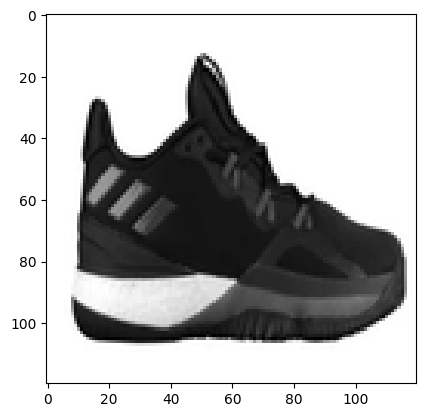

In [45]:
plt.imshow(train_data[35][0],cmap='gist_gray')
plt.show()                                          #checks

In [46]:
import keras
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten

In [47]:
model = Sequential()

model.add(Conv2D(32,(5,5), activation='relu', input_shape=(120,120,1)))
model.add(Conv2D(32,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5), activation='relu'))
model.add(Conv2D(64,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5), activation='relu'))
model.add(Conv2D(64,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())                      #converting to matrix to array

model.add(Dense(512, activation='relu'))       #1 neuron coonected to another   #512 neurons → learns patterns from features
model.add(Dense(2, activation='softmax'))  # adidas or nike 2 options so last layer has 2 neurons.

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) #optimizer updates model weights during training

In [37]:
x = np.array([i[0] for i in train_data]).reshape(-1,IMG_SIZE,IMG_SIZE,1) #-1 idont konw how many images are there 1 is at atime one image should be taken
y = np.array([i[1] for i in train_data])

model.fit(x,y,epochs=20)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4900 - loss: 0.7454
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5000 - loss: 0.6921
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6500 - loss: 0.6838
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5000 - loss: 0.6527
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7600 - loss: 0.5235
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7500 - loss: 0.7617
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8300 - loss: 0.4418
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7400 - loss: 0.5690
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7700 - loss: 0.5231
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8600 - loss: 0.3513
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8500 - loss: 0.3690
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8900 - loss: 0.2989
Epoch 13/20
4/4 

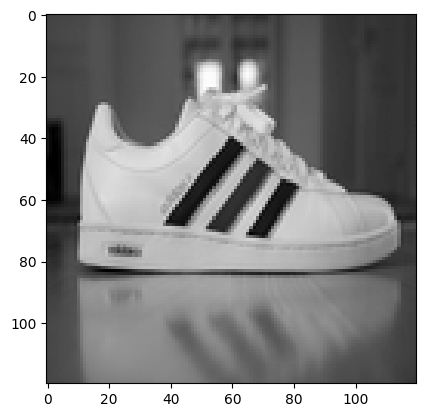

In [38]:
img = Image.open('/content/sample_data/adidastest.jpg')
img = img.convert('L')  # grayscale
img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
plt.imshow(np.array(img),cmap='gist_gray')
plt.show()                                          #checks

In [39]:
model.predict(np.array(img).reshape(-1,IMG_SIZE,IMG_SIZE,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


array([[0., 1.]], dtype=float32)